In [ ]:
# install Roboflow and helpers

%pip install roboflow python-dotenv
!pip install -U roboflow

from roboflow import Roboflow
from dotenv import load_dotenv
from google.colab import userdata
import os
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict
import yaml
import matplotlib.pyplot as plt

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")
api_key = os.getenv("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=api_key)


In [3]:
# Download the dataset from a Roboflow workspace
WORKSPACE = "caretech-qnw0y"                # your Roboflow workspace slug
PROJECT   = "v1-caretech-combined-dataset"  # your project slug
VERSION   = 1                               # dataset version number
FORMAT    = "yolov8"                        # export format (e.g. "yolov5", "coco", "voc")

project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)
dataset = version.download(FORMAT)

print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to [V1]-CareTech-Combined-Dataset-1 in yolov8:: 100%|██████████| 58572/58572 [00:11<00:00, 5093.53it/s]


Dataset location: /content/[V1]-CareTech-Combined-Dataset-1


In [4]:
!mv "/content/[V1]-CareTech-Combined-Dataset-1" "/content/V1-CareTech-Combined-Dataset-1"

In [5]:
os.environ["AUDREY_LAHARI_ROBOFLOW_API_KEY"] = userdata.get("AUDREY_LAHARI_ROBOFLOW_API_KEY")
api_key = os.getenv("AUDREY_LAHARI_ROBOFLOW_API_KEY")

rf_al = Roboflow(api_key=api_key)

In [ ]:
# training the baseline model with the original dataset to get the baseline metrics
# Chosen model: yolov26, 70 epochs, img_size=640x640, train from pretrained COCO images

WORKSPACE_SLUG = "caretech-audrey-lahari"
workspace = rf_al.workspace(WORKSPACE_SLUG)
workspace.upload_dataset(
   "/content/V1-CareTech-Combined-Dataset-1", # dataset path
   "baseline-dataset-l9pzh", # project id (slug)
   num_workers=10,
   project_license="MIT",
   project_type="object-detection",
   batch_name='baseline-dataset',
   num_retries=0,
   is_prediction=False,
)

Model: yolov26, epochs=70, img_size=640x640

Dataset: Original combined dataset

Metrics:
*   mAP@50: 68.5%
*   mAP@50:95: 54.07%
*   Precision: 67.4%
*   Recall: 61.9%



In [ ]:
# make a copy of the dataset for abalation
!cp -R "/content/V1-CareTech-Combined-Dataset-1" "/content/ablated-V1-CareTech-Combined-Dataset-1"

Train label files: 20509

Top  20  Classes by image count:
miso-soup: 238 images
rice: 237 images
ramen-noodle: 217 images
beef-curry: 162 images
hamburger: 152 images
toast: 141 images
egg-sunny-side-up: 128 images
green-salad: 123 images
sandwiches: 118 images
sushi: 117 images
pork-cutlet-on-rice: 112 images
grilled-pacific-saury: 110 images
fried-rice: 109 images
udon-noodle: 107 images
pizza: 103 images
soba-noodle: 102 images
spaghetti: 99 images
cutlet-curry: 95 images
takoyaki: 95 images
tempura-bowl: 95 images


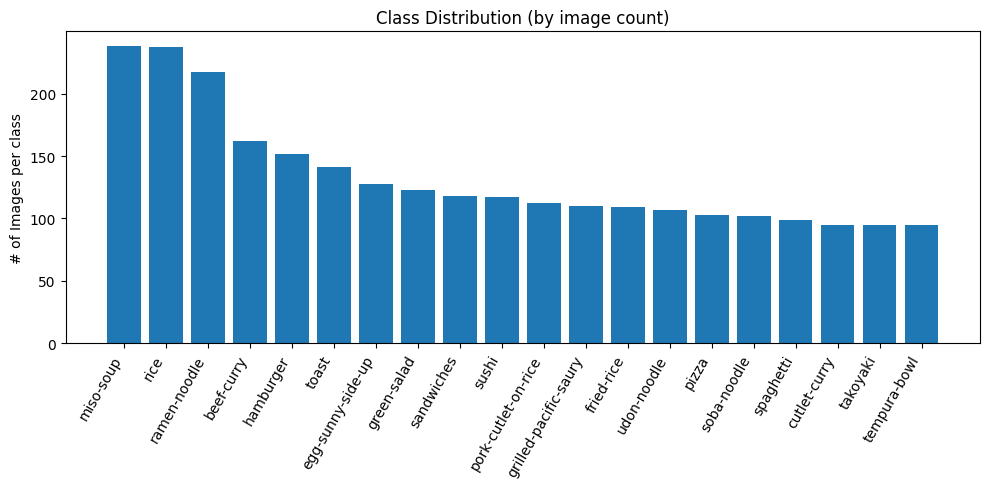

In [7]:
# count how many images per class, show top 20

def count_images_per_class(ds,labels_dir,id_to_name, top_n, graph):
  image_count = {} # for each class, how many images contain that class
  label_files_by_class = defaultdict(list) # for each class, which images contain that class

  label_files = sorted(labels_dir.glob("*.txt"))
  print("Train label files:", len(label_files))

  for lf in label_files:
      if lf.stat().st_size == 0: # if image has no annotations, skip
          continue
      classes = set()
      with open(lf, "r") as f:
          for line in f:
              arr = line.strip().split()
              if not line:
                  continue
              cls = int(arr[0])
              classes.add(cls)
      for cls in classes:
          image_count[cls] = image_count.get(cls, 0) + 1
          label_files_by_class[cls].append(lf)

  TOP_N = top_n
  print("\nTop ", TOP_N, " Classes by image count:")
  top_classes = sorted(image_count.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
  for cls, count in top_classes:
      print(f"{id_to_name[cls]}: {count} images")

  # graph histogram of number of images per class (for top N classes)
  if graph:
    names  = [id_to_name[cls] for cls, count in top_classes]
    counts = [count for cls, count in top_classes]

    plt.figure(figsize=(10, 5))
    plt.bar(names, counts)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("# of Images per class")
    plt.title("Class Distribution (by image count)")
    plt.tight_layout()
    plt.show()

  return image_count, label_files_by_class

ds = Path("/content/V1-CareTech-Combined-Dataset-1")
labels_dir = ds / "train" / "labels"
with open(ds / "data.yaml", "r") as f:
      data = yaml.safe_load(f)
id_to_name = {i: name for i, name in enumerate(data["names"])} # get class names
image_count, label_files_by_class = count_images_per_class(ds,labels_dir,id_to_name, 20, True)

Found 692 candidate images
Removing 69 images (~10%)
Train label files: 20440

Top  20  Classes by image count:
rice: 215 images
miso-soup: 208 images
ramen-noodle: 200 images
beef-curry: 162 images
hamburger: 152 images
toast: 141 images
egg-sunny-side-up: 128 images
green-salad: 123 images
sandwiches: 118 images
sushi: 117 images
pork-cutlet-on-rice: 112 images
grilled-pacific-saury: 110 images
fried-rice: 109 images
udon-noodle: 107 images
pizza: 103 images
soba-noodle: 102 images
spaghetti: 99 images
cutlet-curry: 95 images
takoyaki: 95 images
tempura-bowl: 95 images


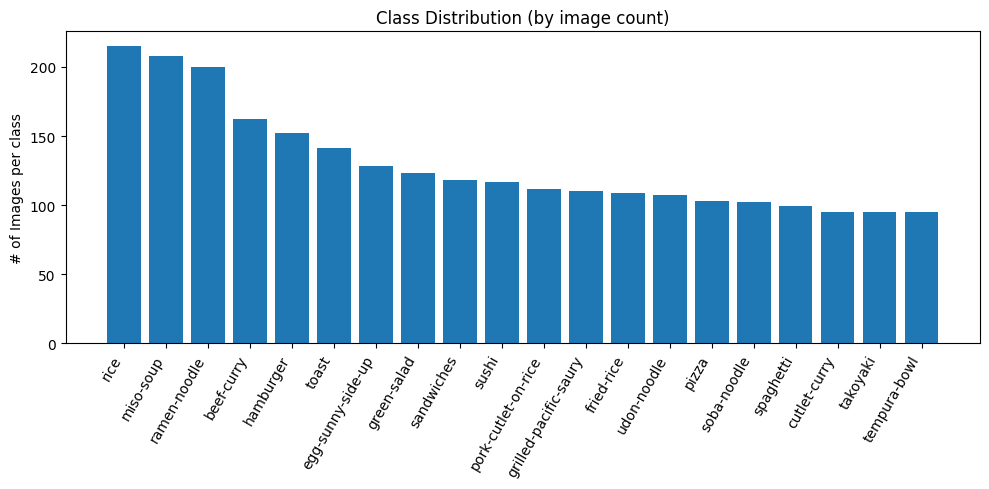

In [ ]:
# removing 10% of images that contain the classes miso-soup, rice, and/or ramen-noodle

ds_abl = Path("/content/ablated-V1-CareTech-Combined-Dataset-1")
labels_dir = ds_abl / "train" / "labels"
label_files = sorted(labels_dir.glob("*.txt"))
image_dir = ds_abl / "train" / "images"
with open(ds_abl / "data.yaml", "r") as f:
    data = yaml.safe_load(f)
id_to_name = {i: name for i, name in enumerate(data["names"])} # get class names

target_classes = ['miso-soup', 'rice', 'ramen-noodle']
ablation_ratio = 0.10
random.seed(42)

# generate list of candidate images to remove 10% from
candidate_images = []
for lf in label_files:
    if lf.stat().st_size == 0: # if image has no annotations, skip
        continue
    with open(lf, "r") as f:
        for line in f:
          # check if this image contains any target class
          arr = line.strip().split()
          if not line:
              continue
          class_id = int(arr[0])
          if id_to_name[class_id] in target_classes:
              image_file = lf.parent / lf.name.replace(".txt", ".jpg")
              candidate_images.append(image_file)
              break

# randomly selecte 10% to delete
num_to_remove = int(len(candidate_images) * ablation_ratio)
images_to_remove = random.sample(candidate_images, num_to_remove)
print(f"Found {len(candidate_images)} candidate images")
print(f"Removing {num_to_remove} images (~10%)")

# delete them
for img in images_to_remove:
    img_path = os.path.join(image_dir, img)
    label_path = os.path.join(labels_dir, img.parent/img.name.replace(".jpg", ".txt"))
    if os.path.exists(img_path):
        os.remove(img_path)
    if os.path.exists(label_path): # remove both the image and the label
        os.remove(label_path)

# re-check image count per class
count_images_per_class(ds_abl,labels_dir,id_to_name)

In [ ]:
# training the baseline model with dataset ablation

WORKSPACE_SLUG = "caretech-audrey-lahari"
workspace = rf_al.workspace(WORKSPACE_SLUG)
workspace.upload_dataset(
   "/content/ablated-V1-CareTech-Combined-Dataset-1", # dataset path
   "ablated-dataset-10", # project id (slug)
   num_workers=10,
   project_license="MIT",
   project_type="object-detection",
   batch_name='ablated-dataset-10',
   num_retries=0,
   is_prediction=False,
)

Model: yolov26, epochs=70, img_size=640x640

Dataset: 10% majority class targeted ablation

Metrics:
*   mAP@50: 68.6%
*   mAP@50:95: 53.36%
*   Precision: 65.3%
*   Recall: 63.4%

Notes:
* better recall than previous dataset
* still some class imbalance


In [ ]:
# find number of classes
print(len(label_files_by_class))

258


In [27]:
# count how many images per class, show all
image_count, label_files_by_class = count_images_per_class(ds,labels_dir,id_to_name, 258, False)
# max 238 vs min 36 -> 6.6x imbalance
'''
top 5 classes:
miso-soup: 61%
rice: 66%
ramen: 87%
beef curry: 86%
hamburger: 88%

bottom 5 classes:
japanese-tofu-and-vegetable-chowder: 48%
rice-ball: 61%
sweet-and-sour-pork: 70%
orange: 27%
apple: 36%

chowder, orange, and apple need to be upsampled/augmented to balance the dataset
'''

Train label files: 20509

Top  258  Classes by image count:
miso-soup: 238 images
rice: 237 images
ramen-noodle: 217 images
beef-curry: 162 images
hamburger: 152 images
toast: 141 images
egg-sunny-side-up: 128 images
green-salad: 123 images
sandwiches: 118 images
sushi: 117 images
pork-cutlet-on-rice: 112 images
grilled-pacific-saury: 110 images
fried-rice: 109 images
udon-noodle: 107 images
pizza: 103 images
soba-noodle: 102 images
spaghetti: 99 images
cutlet-curry: 95 images
takoyaki: 95 images
tempura-bowl: 95 images
natto: 94 images
japanese-style-pancake: 93 images
beef-noodle: 92 images
chip-butty: 91 images
eels-on-rice: 90 images
fried-noodle: 90 images
sashimi-bowl: 90 images
tempura-udon: 90 images
chinese-soup: 89 images
jiaozi: 89 images
fried-chicken: 88 images
dipping-noodles: 85 images
sashimi: 85 images
beef-bowl: 83 images
chicken-n-egg-on-rice: 83 images
cold-tofu: 83 images
fish-ball-soup: 83 images
gratin: 83 images
oxtail-soup: 83 images
salt-and-pepper-fried-shrim

In [12]:
# creating a new dataset with just the minority class images to upscale & augment those images in Roboflow
# "minority classes" = classes whose mAP50 < 30%
# will later merge that mini-dataset with the ablated dataset to create a class-balanced dataset
'''
classes whose mAP50 < 30%:
Ayam-goreng
Chicken-cutlet
Chip-butty
Fried-fish
Ganmodoki
Meat-loaf
Orange
Rice-crispy-pork
'''
min_classes = [
    "ayam-goreng",
    "chicken-cutlet",
    "chip-butty",
    "fried-fish",
    "ganmodoki",
    "meat-loaf",
    "orange",
    "rice-crispy-pork",
]
# original id → new id
old_to_new = {n: i for i, n in enumerate(min_classes)}
src = Path("/content/V1-CareTech-Combined-Dataset-1")
dst = Path("/content/minority-class-dataset")
(dst / "train/images").mkdir(parents=True, exist_ok=True)
(dst / "train/labels").mkdir(parents=True, exist_ok=True)
labels_dir = src / "train/labels"
images_dir = src / "train/images"

for label_file in labels_dir.glob("*.txt"):
    with open(label_file) as f:
        lines = f.readlines()
    new_lines = []
    for line in lines:
        arr = line.strip().split()
        if not arr:
          continue
        cls = int(arr[0])
        if id_to_name[cls] in min_classes: # only adds the annotations of the minority classes
            new_cls = old_to_new[id_to_name[cls]]
            arr[0] = str(new_cls) # map minority classes to new IDs for the new dataset
            new_lines.append(" ".join(arr))
    if not new_lines: # if this image does not contain the minority classes, skip it
        continue
    # write label to new dataset
    dst_label = dst / "train/labels" / label_file.name
    with open(dst_label, "w") as f:
        f.write("\n".join(new_lines))
    # copy image to new dataset
    image_file = images_dir / label_file.name.replace(".txt", ".jpg")
    if image_file.exists():
        shutil.copy(image_file, dst / "train/images" / image_file.name)

# create the data.yaml
data_yaml = {
    "path": str(dst),
    "train": "train/images",
    "val": "train/images",
    "names": min_classes
}
with open(dst / "data.yaml", "w") as f:
    yaml.safe_dump(data_yaml, f)

Images: 585
Labels: 585
Classes: ['ayam-goreng', 'chicken-cutlet', 'chip-butty', 'fried-fish', 'ganmodoki', 'meat-loaf', 'orange', 'rice-crispy-pork']
Train label files: 585

Top  8  Classes by image count:
apple: 91 images
bagel: 81 images
ayam-goreng: 79 images
almond-jelly: 78 images
ayam-bakar: 75 images
adobo: 72 images
apple-pie: 70 images
babi-guling: 39 images


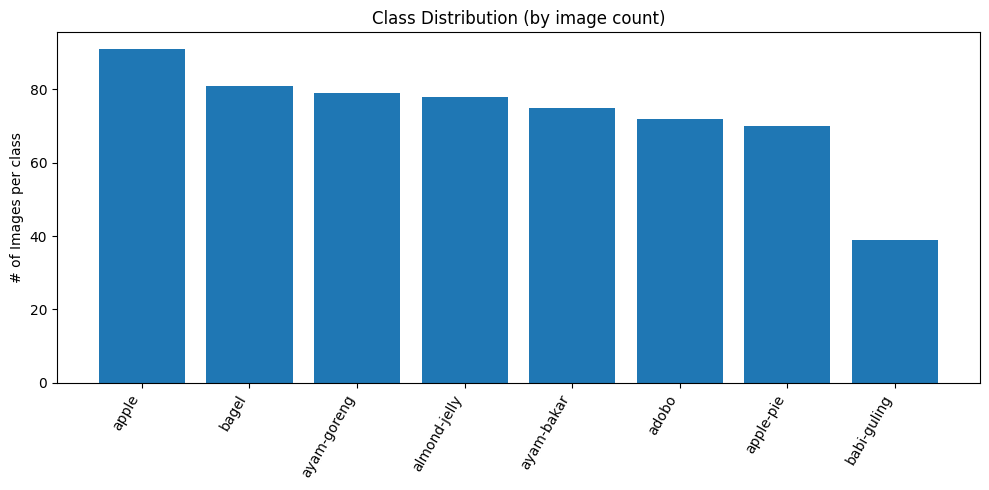

In [17]:
# testing the above code
print("Images:", len(list((dst / "train/images").glob("*"))))
print("Labels:", len(list((dst / "train/labels").glob("*"))))
print("Classes:", min_classes)
labels_dir = dst / "train/labels"
image_count, label_files_by_class = count_images_per_class(dst,labels_dir,id_to_name, 8, True)

In [ ]:
# training the baseline model with the class balanced dataset
# using ablated dataset as the base, upsampling/augmenting each class with mAP50 < 30%.

WORKSPACE_SLUG = "caretech-audrey-lahari"
workspace = rf_al.workspace(WORKSPACE_SLUG)
workspace.upload_dataset(
   "/content/minority-class-dataset", # dataset path
   "minority-class-dataset", # project id (slug)
   num_workers=10,
   project_license="MIT",
   project_type="object-detection",
   batch_name='balanced-dataset',
   num_retries=0,
   is_prediction=False,
)

'''
Augmentations on minority class dataset:
Brightness — 20%
Saturation — 10%
Hue — 5%
Blur — 10%
Rotation — 7%
Horizontal flip
Shear — 5%
Increase mini-dataset by 3x
'''

Model: yolov26, epochs=70, img_size=640x640

Dataset: class-balanced dataset

Metrics:
*   mAP@50: 68.1%
*   mAP@50:95: 53.36%
*   Precision: 69.4%
*   Recall: 59.4%


Notes:
* miso-soup class is frequently missed
* omelet is often confused with omelet-with-fried-rice
* tempura-udon needs more data
* worse recall than previous dataset